<h1><center><b>💻 Practice 11:</b> </br> High-order Proximity-aware GRL</center></h1>

# 1. LINE: Large-scale Information Network Embedding

## 1.1. Sampling method for Negative Samples 

In [5]:
import numpy as np

# Create an alias table from a given probability distribution. It's used for efficient sampling of negative samples
def create_alias_table(area_ratio):
    """

    :param area_ratio: sum(area_ratio)=1
    :return: accept,alias
    """
    l = len(area_ratio)
    accept, alias = [0] * l, [0] * l
    small, large = [], []
    area_ratio_ = np.array(area_ratio) * l
    for i, prob in enumerate(area_ratio_):
        if prob < 1.0:
            small.append(i)
        else:
            large.append(i)

    while small and large:
        small_idx, large_idx = small.pop(), large.pop()
        accept[small_idx] = area_ratio_[small_idx]
        alias[small_idx] = large_idx
        area_ratio_[large_idx] = area_ratio_[large_idx] - \
                                 (1 - area_ratio_[small_idx])
        if area_ratio_[large_idx] < 1.0:
            small.append(large_idx)
        else:
            large.append(large_idx)

    while large:
        large_idx = large.pop()
        accept[large_idx] = 1
    while small:
        small_idx = small.pop()
        accept[small_idx] = 1

    return accept, alias

# This function performs alias sampling
def alias_sample(accept, alias):
    """

    :param accept:
    :param alias:
    :return: sample index
    """
    N = len(accept)
    i = int(np.random.random() * N) # Selects an index i based on a uniform random variable
    r = np.random.random()
    # Returns the selected index if a secondary random check is below the accept threshold; otherwise, returns the alias index
    if r < accept[i]:
        return i
    else:
        return alias[i]

## 1.2. Preprocess a graph

In [6]:
# Creates dictionaries to map nodes to indices (node2idx) and indices to nodes (idx2node)
def preprocess_nxgraph(graph):
    node2idx = {}
    idx2node = []
    node_size = 0
    for node in graph.nodes():
        node2idx[node] = node_size
        idx2node.append(node)
        node_size += 1
    return idx2node, node2idx

## 1.3. Create model: set up embeddings and define the model used for training

In [7]:
import math
import random

'''
create_model(numNodes, embedding_size, order='second')
This function initializes the embeddings and defines the model.

Input:

numNodes: The number of nodes in the graph.
embedding_size: The size of the embedding vectors.
order: The order of proximity to be used ('first' or 'second').
Output:

model: A function that computes the dot product of embeddings for given node pairs.
embeddings: A dictionary containing the initialized embeddings.
'''
# sigmoid function, line_loss function, reduce_sum function for calculating the logistic loss between true value and predicted value
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def line_loss(y_true, y_pred):
    return -np.mean(np.log(sigmoid(y_true * y_pred)))


def reduce_sum(x, axis=None, keepdims=False):
    return np.sum(x, axis=axis, keepdims=keepdims)

# This function initializes the embeddings and defines the model. 
def create_model(numNodes, embedding_size, order='second'):
    # Randomly initializes embedding vectors for each node
    embeddings = {
        'first': np.random.rand(numNodes, embedding_size),
        'second': np.random.rand(numNodes, embedding_size),
        'context': np.random.rand(numNodes, embedding_size)
    }
    # Computes the dot product for first-order and second-order proximity between nodes
    def model(v_i, v_j):
        v_i_emb = embeddings['first'][v_i]
        v_j_emb = embeddings['first'][v_j]
        v_i_emb_second = embeddings['second'][v_i]
        v_j_context_emb = embeddings['context'][v_j]

        first_order = reduce_sum(v_i_emb * v_j_emb, axis=-1)
        second_order = reduce_sum(v_i_emb_second * v_j_context_emb, axis=-1)

        if order == 'first':
            return first_order
        elif order == 'second':
            return second_order
        else:
            return first_order, second_order

    return model, embeddings

## 1.4. Create LINE

In [8]:
class LINE:
    # Sets up the LINE model with graph, embedding size, and other parameters
    # The constructor method where the model is initialized with the graph, embedding size, negative ratio, and order of proximity
    def __init__(self, graph, embedding_size=8, negative_ratio=5, order='second'):
        """
        :param graph:
        :param embedding_size:
        :param negative_ratio:
        :param order: 'first', 'second', 'all'
        """
        if order not in ['first', 'second', 'all']:
            raise ValueError('mode must be first, second, or all')

        self.graph = graph
        self.idx2node, self.node2idx = self.preprocess_nxgraph(graph)
        self.use_alias = True

        self.rep_size = embedding_size
        self.order = order

        self._embeddings = {}
        self.negative_ratio = negative_ratio
        self.order = order

        self.node_size = graph.number_of_nodes()
        self.edge_size = graph.number_of_edges()
        self.samples_per_epoch = self.edge_size * (1 + negative_ratio)

        self._gen_sampling_table()
        self.reset_model()

    # Preprocesses the graph to create node indices
    def preprocess_nxgraph(self, graph):
        idx2node = list(graph.nodes())
        node2idx = {node: idx for idx, node in enumerate(idx2node)}
        return idx2node, node2idx

    # Reset the training configuration with the given batch size and times
    def reset_training_config(self, batch_size, times):
        self.batch_size = batch_size
        self.steps_per_epoch = ((self.samples_per_epoch - 1) // self.batch_size + 1) * times

    # Resets the model and initializes the batch iterator
    def reset_model(self, opt='adam'):
        self.model, self.embeddings = create_model(self.node_size, self.rep_size, self.order)
        self.batch_it = self.batch_iter(self.node2idx)

    # Generates sampling tables for negative sampling
    def _gen_sampling_table(self):
        # create sampling table for vertex
        power = 0.75
        numNodes = self.node_size
        node_degree = np.zeros(numNodes)  # out degree
        node2idx = self.node2idx

        for edge in self.graph.edges():
            node_degree[node2idx[edge[0]]] += self.graph[edge[0]][edge[1]].get('weight', 1.0)

        total_sum = sum([math.pow(node_degree[i], power) for i in range(numNodes)])
        norm_prob = [float(math.pow(node_degree[j], power)) / total_sum for j in range(numNodes)]

        self.node_accept, self.node_alias = self.create_alias_table(norm_prob)

        # create sampling table for edge
        numEdges = self.graph.number_of_edges()
        total_sum = sum([self.graph[edge[0]][edge[1]].get('weight', 1.0) for edge in self.graph.edges()])
        norm_prob = [self.graph[edge[0]][edge[1]].get('weight', 1.0) * numEdges / total_sum for edge in self.graph.edges()]

        self.edge_accept, self.edge_alias = self.create_alias_table(norm_prob)

    # Construct an alias table for efficient negative sampling from a non-uniform distribution
    def create_alias_table(self, norm_prob):
        length = len(norm_prob)
        accept = np.zeros(length, dtype=np.float32)
        alias = np.zeros(length, dtype=np.int32)
        small = []
        large = []
        scaled_prob = np.array(norm_prob) * length
        for i, prob in enumerate(scaled_prob):
            if prob < 1.0:
                small.append(i)
            else:
                large.append(i)
        while small and large:
            small_idx = small.pop()
            large_idx = large.pop()
            accept[small_idx] = scaled_prob[small_idx]
            alias[small_idx] = large_idx
            scaled_prob[large_idx] = scaled_prob[large_idx] - (1.0 - scaled_prob[small_idx])
            if scaled_prob[large_idx] < 1.0:
                small.append(large_idx)
            else:
                large.append(large_idx)
        while large:
            large_idx = large.pop()
            accept[large_idx] = 1
        while small:
            small_idx = small.pop()
            accept[small_idx] = 1
        return accept, alias

    # Performs alias sampling
    def alias_sample(self, accept, alias):
        N = len(accept)
        i = int(np.random.rand() * N) 
        if np.random.rand() < accept[i]:
            return i
        else:
            return alias[i]
        
    # Generates batches of positive and negative samples for training
    def batch_iter(self, node2idx):
        edges = [(node2idx[x[0]], node2idx[x[1]]) for x in self.graph.edges()]
        data_size = self.graph.number_of_edges()
        shuffle_indices = np.random.permutation(np.arange(data_size))
        mod = 0
        mod_size = 1 + self.negative_ratio
        h = []
        t = []
        sign = 0
        count = 0
        start_index = 0
        end_index = min(start_index + self.batch_size, data_size)
        while True:
            if mod == 0:
                h = []
                t = []
                for i in range(start_index, end_index):
                    if random.random() >= self.edge_accept[shuffle_indices[i]]:
                        shuffle_indices[i] = self.edge_alias[shuffle_indices[i]]
                    cur_h = edges[shuffle_indices[i]][0]
                    cur_t = edges[shuffle_indices[i]][1]
                    h.append(cur_h)
                    t.append(cur_t)
                sign = np.ones(len(h))
            else:
                sign = np.ones(len(h)) * -1
                t = [self.alias_sample(self.node_accept, self.node_alias) for _ in range(len(h))]

            if self.order == 'all':
                yield ([np.array(h), np.array(t)], [sign, sign])
            else:
                yield ([np.array(h), np.array(t)], [sign])
            mod += 1
            mod %= mod_size
            if mod == 0:
                start_index = end_index
                end_index = min(start_index + self.batch_size, data_size)

            if start_index >= data_size:
                count += 1
                mod = 0
                h = []
                shuffle_indices = np.random.permutation(np.arange(data_size))
                start_index = 0
                end_index = min(start_index + self.batch_size, data_size)

    # Retrieve the learned embeddings for all nodes
    def get_embeddings(self):
        self._embeddings = {}
        if self.order == 'first':
            embeddings = self.embeddings['first']
        elif self.order == 'second':
            embeddings = self.embeddings['second']
        else:
            embeddings = np.hstack((self.embeddings['first'], self.embeddings['second']))
        idx2node = self.idx2node
        for i, embedding in enumerate(embeddings):
            self._embeddings[idx2node[i]] = embedding
        return self._embeddings

    # Runs through epochs and steps, generating batches and computing losses for first-order, second-order, or both proximities
    def train(self, batch_size=1024, epochs=1, initial_epoch=0, verbose=1, times=1):
        self.reset_training_config(batch_size, times)
        for epoch in range(initial_epoch, epochs):
            for step in range(self.steps_per_epoch):
                batch = next(self.batch_it)
                inputs, targets = batch
                v_i, v_j = inputs
                if self.order == 'all':
                    sign_first, sign_second = targets
                    first_order, second_order = self.model(v_i, v_j)
                    loss_first = line_loss(sign_first, first_order)
                    loss_second = line_loss(sign_second, second_order)
                    loss = loss_first + loss_second
                else:
                    sign = targets
                    preds = self.model(v_i, v_j)
                    loss = line_loss(sign, preds)
                if verbose:
                    print(f'Epoch {epoch + 1}/{epochs}, Step {step + 1}/{self.steps_per_epoch}, Loss: {loss}')
        return

## 1.5. Train and visualize LINE embeddings

Epoch 1/50, Step 1/1, Loss: 1.6070051272606757e-13
Epoch 2/50, Step 1/1, Loss: 31.519916112445998
Epoch 3/50, Step 1/1, Loss: 31.48426312150329
Epoch 4/50, Step 1/1, Loss: 31.308819269176293
Epoch 5/50, Step 1/1, Loss: 31.226724410332682
Epoch 6/50, Step 1/1, Loss: 31.20381669954727
Epoch 7/50, Step 1/1, Loss: 1.6070051272606752e-13
Epoch 8/50, Step 1/1, Loss: 31.205924815577948
Epoch 9/50, Step 1/1, Loss: 31.550768350682002
Epoch 10/50, Step 1/1, Loss: 31.2927195352456
Epoch 11/50, Step 1/1, Loss: 31.320092023908444
Epoch 12/50, Step 1/1, Loss: 30.719521261658475
Epoch 13/50, Step 1/1, Loss: 1.6070051272606752e-13
Epoch 14/50, Step 1/1, Loss: 31.636483881888743
Epoch 15/50, Step 1/1, Loss: 31.35455306895213
Epoch 16/50, Step 1/1, Loss: 31.208566695840492
Epoch 17/50, Step 1/1, Loss: 31.086764557481022
Epoch 18/50, Step 1/1, Loss: 31.368974546766985
Epoch 19/50, Step 1/1, Loss: 1.6070051272606752e-13
Epoch 20/50, Step 1/1, Loss: 31.197504518555263
Epoch 21/50, Step 1/1, Loss: 31.136397

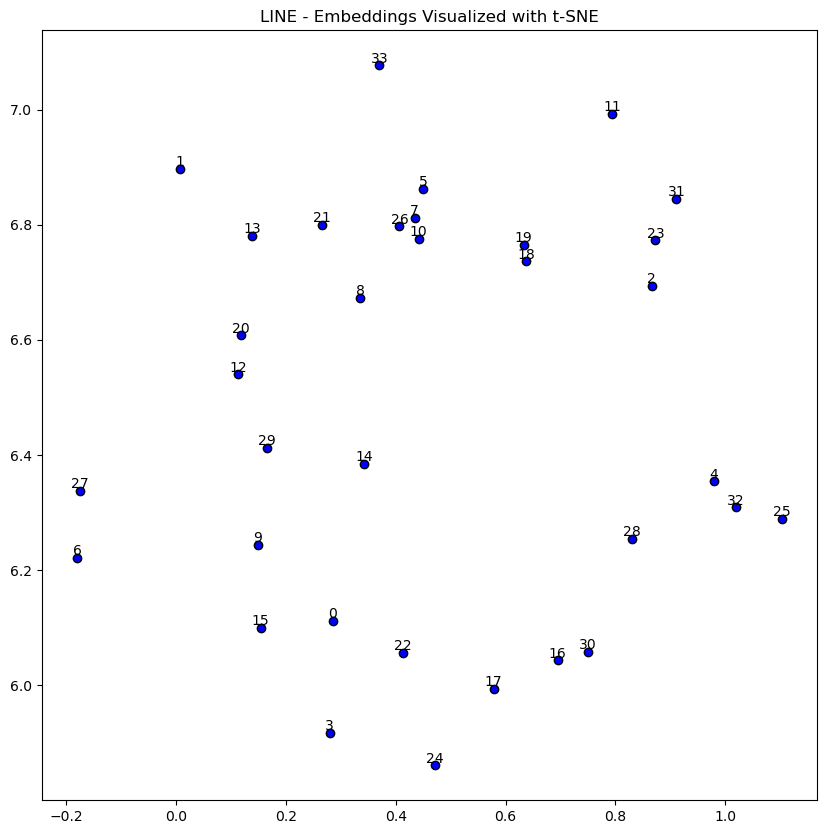

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Load the graph
G = nx.karate_club_graph()

# Initialize the model
model = LINE(G, embedding_size=128, order='second')  # order can be ['first', 'second', 'all']
model.train(batch_size=1024, epochs=50, verbose=2)  # Train the model

# Get the embedding vectors
embeddings = model.get_embeddings()

# Convert embeddings to a numpy array for easier handling
nodes = list(embeddings.keys())
emb_array = np.array([embeddings[node] for node in nodes])

# Use t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(emb_array)

# Plot the 2D embeddings
plt.figure(figsize=(10, 10))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='blue', edgecolors='k')

# Optionally, label the points with node identifiers
for i, node in enumerate(nodes):
    plt.annotate(node, (emb_2d[i, 0], emb_2d[i, 1]), textcoords='offset points', xytext=(0, 2), ha='center')

plt.title('LINE - Embeddings Visualized with t-SNE')
plt.show()


# 2. Scalable Graph Embedding for Asymmetric Proximity (APP)

## 2.1. APP module

Model Setting:
	dimension:		16
Model:
	[APP]
Learning Parameters:
	walk_times:		10
	sample_times:		5
	jumping factor:		0.2
	negative_samples:	5
	alpha:			0.025
	workers:		4
Start Training:
	Alpha: 0.000074	Progress: 100.00 %
Save Model:
	Save to <embeddings.txt>


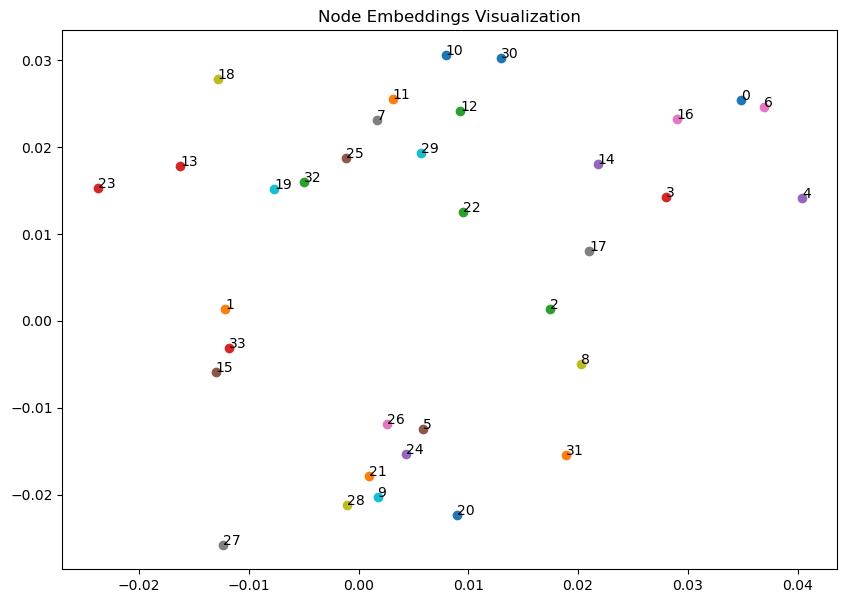

In [17]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

class APP:
    
    def __init__(self):
        self.dim = 0 # Dimension of the embeddings
        self.w_vertex = None # Vertex embeddings
        self.w_context = None # Context embeddings
        self.pnet = None # stores the graph structure
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    #Loads the graph into the pnet attribute. It optionally converts the graph to an undirected graph
    def load_edge_list(self, graph, undirect=True):
        self.pnet = graph
        if undirect:
            self.pnet = self.pnet.to_undirected()
    
    # Save weights to a file for analysis
    def save_weights(self, model_name):
        print("Save Model:")
        with open(model_name, 'w') as model:
            model.write(f"{self.pnet.number_of_nodes()} {self.dim}\n")
            for node in self.pnet.nodes():
                model.write(f"{node}")
                for d in range(self.dim):
                    model.write(f" {self.w_vertex[node][d]}")
                model.write("\n")
        print(f"\tSave to <{model_name}>")

    # Initialization: set the embedding dimensionality and initializes the embeddings for vertices and contexts randomly.
    def init(self, dim):
        self.dim = dim
        print("Model Setting:")
        print(f"\tdimension:\t\t{dim}")
        
        self.w_vertex = {node: (np.random.rand(dim) - 0.5) / dim for node in self.pnet.nodes()}
        self.w_context = {node: (np.random.rand(dim) - 0.5) / dim for node in self.pnet.nodes()}
    
    def train(self, walk_times, sample_times, jump, negative_samples, alpha, workers):
        total = walk_times * self.pnet.number_of_nodes()
        alpha_min = alpha * 0.0001
        _alpha = alpha
        count = 0
        
        print("Model:")
        print("\t[APP]")
        
        print("Learning Parameters:")
        print(f"\twalk_times:\t\t{walk_times}") # Number of random walks to perform per node
        print(f"\tsample_times:\t\t{sample_times}") # Number of times to sample context nodes per random walk
        print(f"\tjumping factor:\t\t{jump}") # Probability of jumping to a random node during a random walk
        print(f"\tnegative_samples:\t{negative_samples}") # Number of negative samples to use per positive sample
        print(f"\talpha:\t\t\t{alpha}") # Learning rate
        print(f"\tworkers:\t\t{workers}") # Number of workers
        
        print("Start Training:")
        
        for t in range(walk_times):
            random_keys = list(self.pnet.nodes())
            random.shuffle(random_keys)
            
            for vid in random_keys:
                for s in range(sample_times):
                    walks = self.random_walk(vid, jump)
                    self.update_pair(walks[0], walks[-1], _alpha, negative_samples)
                
                count += 1
                if count % (total // 100) == 0:
                    _alpha = alpha * (1.0 - count / total)
                    if _alpha < alpha_min:
                        _alpha = alpha_min
                    print(f"\tAlpha: {_alpha:.6f}\tProgress: {count / total * 100:.2f}%", end='\r')
        
        print(f"\tAlpha: {_alpha:.6f}\tProgress: 100.00 %")
    
    # Generates a random walk in the graph starting from a given node
    def random_walk(self, start, jump):
        walk = [start]
        while True:
            current = walk[-1]
            neighbors = list(self.pnet.neighbors(current))
            if not neighbors or random.random() < jump:
                break
            walk.append(random.choice(neighbors))
        return walk
    
    # Update the embeddings based on the positive and negative samples
    def update_pair(self, v1, v2, alpha, negative_samples):
        v1_embedding = self.w_vertex[v1]
        v2_embedding = self.w_context[v2]

        # Positive sample update
        score = np.dot(v1_embedding, v2_embedding)
        gradient = alpha * (1 - self.sigmoid(score))
        self.w_vertex[v1] += gradient * v2_embedding
        self.w_context[v2] += gradient * v1_embedding
        
        # Negative samples update
        for _ in range(negative_samples):
            negative_v = random.choice(list(self.pnet.nodes()))
            if negative_v == v2:
                continue
            
            negative_v_embedding = self.w_context[negative_v]
            score = np.dot(v1_embedding, negative_v_embedding)
            gradient = alpha * (-self.sigmoid(score))
            self.w_vertex[v1] += gradient * negative_v_embedding
            self.w_context[negative_v] += gradient * v1_embedding

# Load the karate club graph
G = nx.karate_club_graph()

# Create APP instance and load the graph
app = APP()
app.load_edge_list(G)

# Initialize the embeddings with a specified dimension
app.init(dim=16)

# Train the model (parameters are examples)
app.train(walk_times=10, sample_times=5, jump=0.2, negative_samples=5, alpha=0.025, workers=4)

# Save the trained weights to a file
app.save_weights("embeddings.txt")

# Extract and visualize the embeddings
embeddings = np.array([app.w_vertex[node] for node in G.nodes()])
plt.figure(figsize=(10, 7))
for i, node in enumerate(G.nodes()):
    plt.scatter(embeddings[i, 0], embeddings[i, 1])
    plt.annotate(node, (embeddings[i, 0], embeddings[i, 1]))
plt.title("Node Embeddings Visualization")
plt.show()

# 3. GraRep: Learning Graph Representations with Global Structural Information

## 3.1. GraRep module

In [21]:
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from argparse import Namespace

def create_inverse_degree_matrix(edges):
    """inverse degree matrix"""
    graph = nx.from_edgelist(edges)
    ind = range(len(graph.nodes()))
    degs = [1.0 / graph.degree(node) for node in range(graph.number_of_nodes())]
    D_1 = sparse.coo_matrix((degs, (ind, ind)),
                            shape=(graph.number_of_nodes(), graph.number_of_nodes()),
                            dtype=np.float32)
    return D_1

def normalize_adjacency(edges):
    """normalize adjacency matrix"""
    D_1 = create_inverse_degree_matrix(edges)
    index_1 = [edge[0] for edge in edges] + [edge[1] for edge in edges]
    index_2 = [edge[1] for edge in edges] + [edge[0] for edge in edges]
    values = [1.0] * len(edges) * 2
    A = sparse.coo_matrix((values, (index_1, index_2)),
                          shape=D_1.shape,
                          dtype=np.float32)
    A = A.dot(D_1)
    return A

class GraRep:

    def __init__(self, A, args):
        self.A = A
        self.args = args
        self._setup_base_target_matrix()

    def _setup_base_target_matrix(self):
        """Create the base target matrix (identity)."""
        n = self.A.shape[0]
        values = [1.0] * n
        indices = list(range(n))
        self.A_hat = sparse.coo_matrix((values, (indices, indices)),
                                       shape=self.A.shape,
                                       dtype=np.float32)

    def _create_target_matrix(self):
        """Create the target matrix = log(A^k) - log(N) (only keep values < 0)."""
        self.A_hat = sparse.coo_matrix(self.A_hat.dot(self.A))
        scores = np.log(self.A_hat.data) - math.log(self.A.shape[0])
        
        # Only keep negative values
        mask = scores < 0
        target_matrix = sparse.coo_matrix((scores[mask],
                                           (self.A_hat.row[mask], self.A_hat.col[mask])),
                                          shape=self.A.shape,
                                          dtype=np.float32)
        return target_matrix

    def optimize(self):
        """Learn embeddings."""
        print("\nRunning GraRep...\n")
        self.embeddings = []
        for step in tqdm(range(self.args.order)):
            target_matrix = self._create_target_matrix()
            svd = TruncatedSVD(n_components=self.args.dimensions,
                               n_iter=self.args.iterations,
                               random_state=self.args.seed)
            svd.fit(target_matrix)
            embedding = svd.transform(target_matrix)
            self.embeddings.append(embedding)
        print("Completed training!")

    def get_embedding_dataframe(self):
        """Return embeddings as a DataFrame"""
        self.embeddings = np.concatenate(self.embeddings, axis=1)
        column_count = self.args.order * self.args.dimensions
        columns = ["ID"] + [f"x_{col}" for col in range(column_count)]
        ids = np.arange(self.embeddings.shape[0]).reshape(-1, 1)
        embeddings_with_id = np.concatenate([ids, self.embeddings], axis=1)
        return pd.DataFrame(embeddings_with_id, columns=columns)

## 3.2. Test on Karate Club dataset

In [24]:
G = nx.karate_club_graph()
edges = list(G.edges())

# Create the normalized adjacency matrix
A = normalize_adjacency(edges)
print(f"✅ Normalized adjacency matrix created: {A.shape[0]} nodes × {A.shape[1]} nodes")

# Set up parameters 
args = Namespace(
    dimensions=8,      
    order=3,           
    seed=42,
    iterations=15,
    output_path=None   
)

model = GraRep(A, args)
model.optimize()

embedding_df = model.get_embedding_dataframe()
print("\nFirst 5 rows:")
display(embedding_df.head())

✅ Normalized adjacency matrix created: 34 nodes × 34 nodes

Running GraRep...



100%|██████████| 3/3 [00:00<00:00, 139.00it/s]

Completed training!

First 5 rows:


,ID,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,...,x_14,x_15,x_16,x_17,x_18,x_19,x_20,x_21,x_22,x_23
0,0.0,-9.726992,8.819340,8.630762,-4.115458,8.695507,-5.639736,-1.887850,-0.199491,-23.892500,...,8.854483,0.267907,-34.491814,-3.402329,-3.501774,-4.460591,-0.964823,0.035680,1.323939,0.186352
1,1.0,-8.599159,7.756849,2.978971,-2.113557,0.580901,1.236684,8.468573,0.304113,-26.544479,...,-0.691471,2.263626,-37.878517,-1.453859,-4.641574,-5.324594,-2.365655,-0.263254,1.474821,0.752447
2,2.0,-10.992453,4.990514,1.867749,8.975270,3.720616,3.669310,-0.200084,-1.215296,-30.916428,...,1.710393,-3.764309,-36.569691,0.547171,-6.217175,-2.757597,-3.401050,-0.113938,1.203489,0.169224
3,3.0,-7.929075,7.440377,-0.245055,-1.348639,1.096187,2.998386,-0.148012,-0.281533,-28.646360,...,-0.292522,-2.452476,-41.235722,-3.096457,-6.378357,-5.446194,-2.472107,-0.306945,1.298274,0.474119
4,4.0,-3.284882,4.022686,-2.088951,1.344898,-2.629705,-4.271417,-0.265546,0.654438,-22.836119,...,-0.287244,1.255690,-36.620323,13.852821,9.880646,-1.388012,0.898926,-0.946165,-0.058242,-0.351165


## 3.3. Visualization

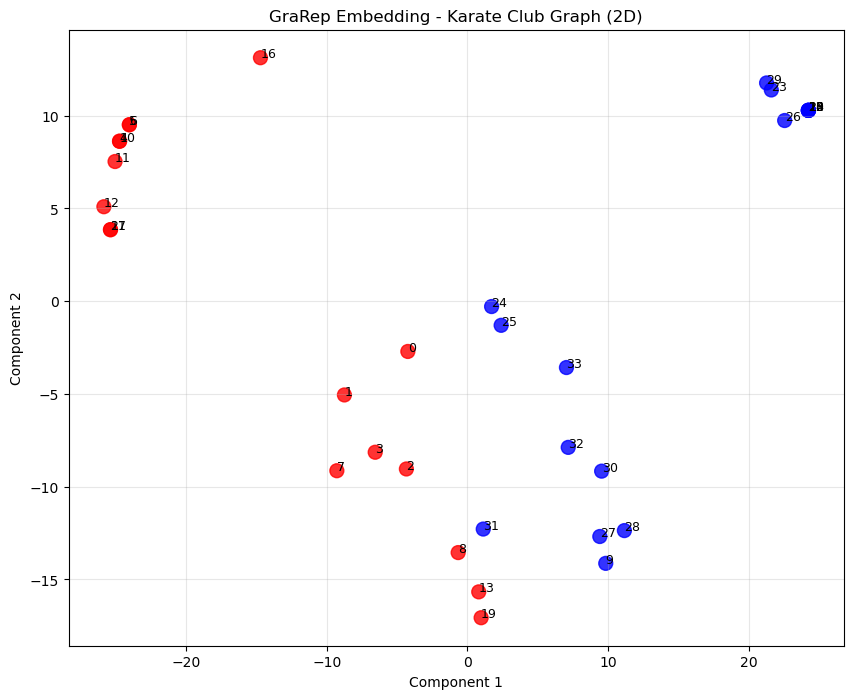

In [25]:
# Use PCA to reduce the dimensionality of the embeddings to 2D for visualization
embeddings_2d = PCA(n_components=2, random_state=42).fit_transform(
    embedding_df.iloc[:, 1:].values
)

club_labels = [G.nodes[i]['club'] for i in range(len(G))]
club_colors = ['red' if label == 'Mr. Hi' else 'blue' for label in club_labels]

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=club_colors, s=100, alpha=0.8)
for i, txt in enumerate(range(len(G))):
    plt.annotate(txt, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9)

plt.title("GraRep Embedding - Karate Club Graph (2D)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Asymmetric Transitivity Preserving Graph Embedding (HOPE)

## 4.1. Create HOPE

In [6]:
import networkx as nx
import numpy as np
import scipy.sparse.linalg as lg

class HOPE(object):
    def __init__(self, graph, d):
        '''
          d: representation vector dimension
        '''
        self._d = d # The dimension of the representation vector (embedding)
        self._graph = graph.G # Stores the NetworkX graph from the Graph object
        self.g = graph # Stores the Graph object
        self._node_num = graph.node_size # Stores the number of nodes in the graph
        self.learn_embedding() # Learn the embeddings when initializing the object

    def learn_embedding(self):

        graph = self.g.G
        A = nx.to_numpy_array(graph) # Get the adjacency matrix of the graph

        M_g = np.eye(graph.number_of_nodes()) # Create an identity matrix
        M_l = np.dot(A, A) # Compute the squared adjacency matrix

        S = np.dot(np.linalg.inv(M_g), M_l) #  Computes the similarity matrix
        # s: \sigma_k
        u, s, vt = lg.svds(S, k=self._d // 2) # Perform SVD on S, getting the top k singular values/vectors (with k = self._d // 2)
        sigma = np.diagflat(np.sqrt(s)) # Creates a diagonal matrix from the square roots of the singular values
        X1 = np.dot(u, sigma) #Compute the embeddings
        X2 = np.dot(vt.T, sigma) # Compute the embeddings

        self._X = np.concatenate((X1, X2), axis=1) # Placeholder for the final embeddings

    @property
    def vectors(self):
        vectors = {}
        look_back = self.g.look_back_list # list of nodes
        # For each node, the corresponding embedding is added to the vectors dictionary
        for i, embedding in enumerate(self._X):
            vectors[look_back[i]] = embedding
        return vectors

    # Save embeddings to a file
    def save_embeddings(self, filename):
        fout = open(filename, 'w')
        node_num = len(self.vectors.keys())
        fout.write("{} {}\n".format(node_num, self._d))
        for node, vec in self.vectors.items():
            fout.write("{} {}\n".format(node,
                                        ' '.join([str(x) for x in vec])))
        fout.close()

class Graph:
    def __init__(self, nx_G):
        self.G = nx_G # Store graph object 
        self.node_size = self.G.number_of_nodes() #Store the number of nodes in the graph
        self.look_back_list = list(self.G.nodes()) # Store list of nodes in the graph

## 4.2. Train and visualize HOPE

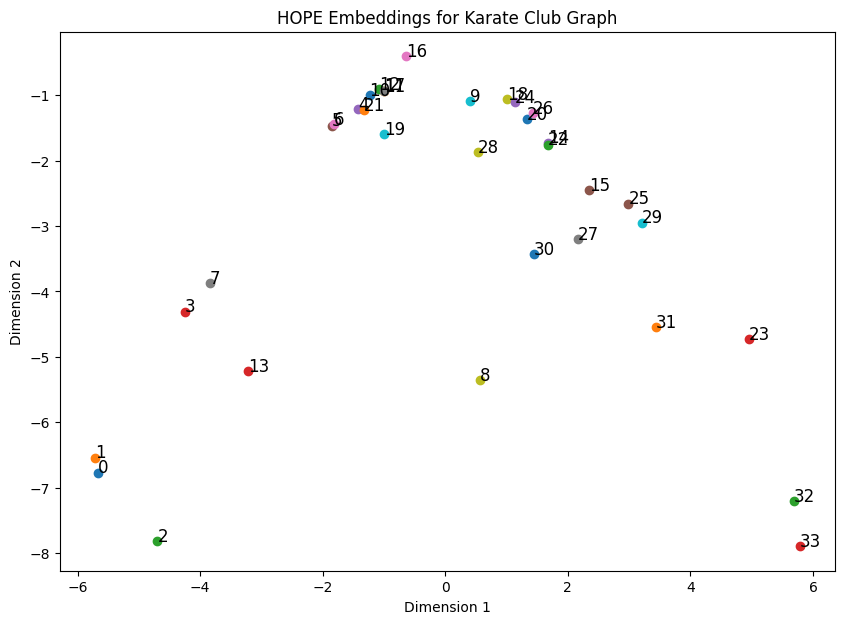

In [7]:
# Create the Karate Club graph
G = nx.karate_club_graph()
graph = Graph(G)

# Initialize HOPE with the graph and desired embedding dimension
hope = HOPE(graph, d=4)

# Get the embeddings
embeddings = hope.vectors

# Visualize the embeddings
def plot_embeddings(embeddings):
    plt.figure(figsize=(10, 7))
    for node, emb in embeddings.items():
        plt.scatter(emb[0], emb[1], marker='o')
        plt.text(emb[0], emb[1], s=str(node), fontsize=12)
    plt.title("HOPE Embeddings for Karate Club Graph")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# Plot the embeddings
plot_embeddings(embeddings)

# 5. Arbitrary-Order Proximity Preserved Network Embedding (AROPE)

## 5.1. AROPE module

In [26]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings("ignore")
from scipy.sparse.linalg import eigs

def Eigen_Reweighting(X, order, coef):
    if order == -1:  # infinity
        assert len(coef) == 1
        coef = coef[0]
        assert np.max(np.absolute(X)) * coef < 1, 'Decaying constant too large.'
        X_H = np.divide(X, 1 - coef * X)
    else:
        assert len(coef) == order
        X_H = coef[0] * X
        X_temp = X
        for i in range(1, order):
            X_temp = np.multiply(X_temp, X)
            X_H += coef[i] * X_temp
    return X_H

def Eigen_TopL(A, d):
    L = d + 10
    lambd = np.array([0])
    while sum(lambd > 0) < d:
        L = L + d
        lambd, X = eigs(A, L)
        lambd, X = lambd.real, X.real
    temp_index = np.absolute(lambd).argsort()[::-1]
    lambd = lambd[temp_index]
    temp_max, = np.where(np.cumsum(lambd > 0) >= d)
    lambd = lambd[:temp_max[0]+1]
    temp_index = temp_index[:temp_max[0]+1]
    X = X[:, temp_index]
    return lambd, X

def Shift_Embedding(lambd, X, order, coef, d):
    lambd_H = Eigen_Reweighting(lambd, order, coef)
    temp_index = np.absolute(lambd_H).argsort()[::-1]
    temp_index = temp_index[:d+1]
    lambd_H = lambd_H[temp_index]
    lambd_H_temp = np.sqrt(np.absolute(lambd_H))
    U = np.dot(X[:, temp_index], np.diag(lambd_H_temp))
    V = np.dot(X[:, temp_index], np.diag(np.multiply(lambd_H_temp, np.sign(lambd_H))))
    return U, V

def AROPE(A, d, order, weights):
    A = A.asfptype()
    lambd, X = Eigen_TopL(A, d)
    r = len(order)
    U_output, V_output = [], []
    for i in range(r):
        U_temp, V_temp = Shift_Embedding(lambd, X, order[i], weights[i], d)
        U_output.append(U_temp)
        V_output.append(V_temp)
    return U_output, V_output

## 5.2. Evaluation

In [27]:
def Precision_Np(Matrix_test, Matrix_train, U, V, Np):
    N, _ = U.shape
    assert N < 30000, 'Network too large. Sample suggested.'
    Sim = U.dot(V.T)
    temp_row, temp_col = np.nonzero(Sim)
    temp_value = Sim[temp_row, temp_col]
    temp_choose = np.logical_and(np.array(Matrix_train[temp_row, temp_col])[0] == 0, temp_row != temp_col)
    temp_row = temp_row[temp_choose]
    temp_col = temp_col[temp_choose]
    temp_value = temp_value[temp_choose]
    temp_index = np.argsort(temp_value)[::-1]
    assert len(temp_index) >= Np, 'Np too large'
    temp_index = temp_index[:int(Np)]
    temp_row, temp_col = temp_row[temp_index], temp_col[temp_index]
    result = np.array(Matrix_test[temp_row, temp_col])[0] > 0
    result = np.divide(np.cumsum(result > 0), np.arange(len(result)) + 1)
    return result

## 5.3. Test on Karate Club dataset

In [35]:
G = nx.karate_club_graph()
N = G.number_of_nodes()
print(f"Number of nodes: {N}")

# Convert the graph to a sparse adjacency matrix
A = nx.to_scipy_sparse_array(G, format='csr')
A = csr_matrix(A)           
A = A + A.T                


d = 8                      # embedding dimension
order = [1, 2, 3, -1]      # proximity orders to consider (1st, 2nd, 3rd, and infinity)
weights = [
    [1.0],                 # order 1
    [1.0, 0.1],            # order 2
    [1.0, 0.1, 0.01],      # order 3
    [0.001]                # order ∞ (decaying constant)
]

# Run AROPE
U_list, V_list = AROPE(A, d, order, weights)

print("Run AROPE completed")
for i, o in enumerate(order):
    print(f"   Proximity order {o if o != -1 else '∞'} → U shape: {U_list[i].shape}")

Number of nodes: 34
Run AROPE completed
   Proximity order 1 → U shape: (34, 9)
   Proximity order 2 → U shape: (34, 9)
   Proximity order 3 → U shape: (34, 9)
   Proximity order ∞ → U shape: (34, 9)


Precision@500 (order=1): 0.3120
Precision@500 (order=2): 0.3040
Precision@500 (order=3): 0.3120
Precision@500 (order=∞): 0.3120


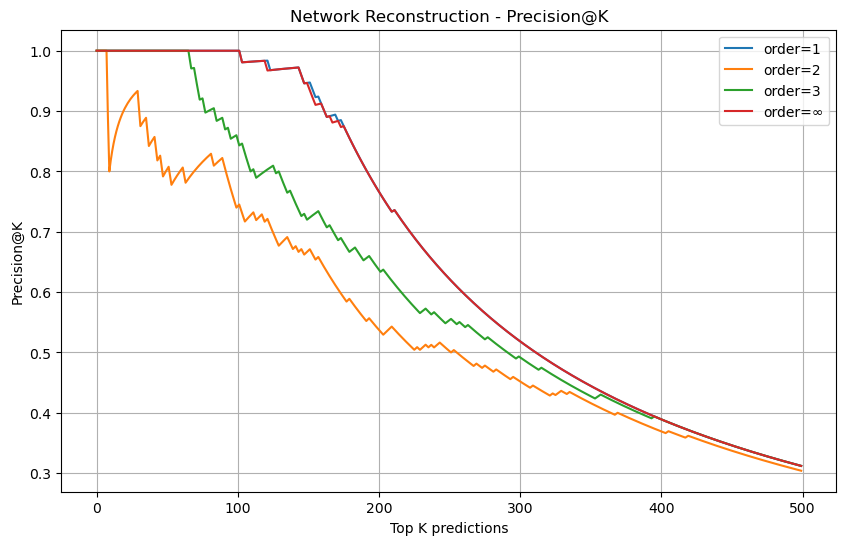

In [32]:
# Network Reconstruction Evaluation
Np = 500
results = []
for i in range(len(order)):
    prec = Precision_Np(A, csr_matrix((N, N)), U_list[i], V_list[i], Np)
    results.append(prec)
    print(f"Precision@500 (order={order[i] if order[i]!=-1 else '∞'}): {prec[-1]:.4f}")

# Draw Precision
plt.figure(figsize=(10, 6))
for i, o in enumerate(order):
    label = f"order={o if o != -1 else '∞'}"
    plt.plot(results[i], label=label)
plt.xlabel("Top K predictions")
plt.ylabel("Precision@K")
plt.title("Network Reconstruction - Precision@K")
plt.legend()
plt.grid(True)
plt.show()

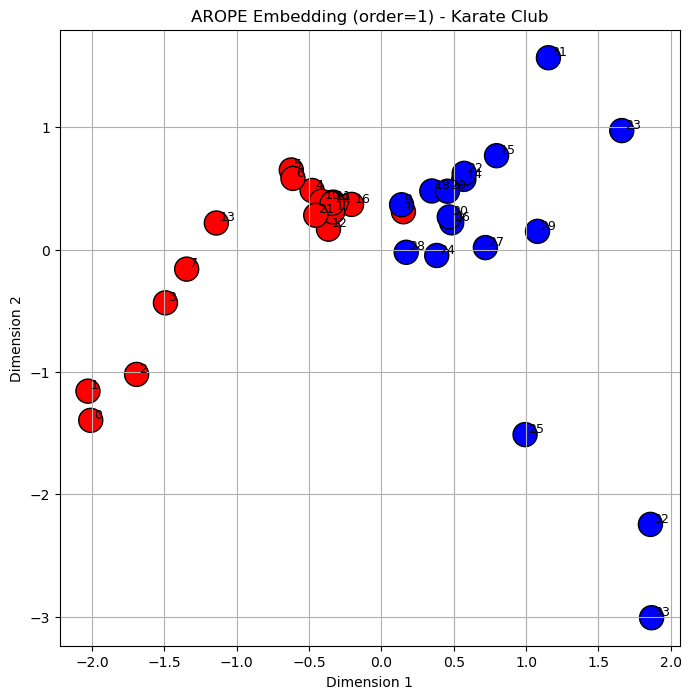

In [34]:
# Take the embedding from the first order proximity for visualization
U = U_list[0]

club_labels = [G.nodes[i]['club'] for i in range(N)]
color_map = ['red' if label == 'Mr. Hi' else 'blue' for label in club_labels]

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
U_2d = pca.fit_transform(U)

plt.figure(figsize=(8, 8))
plt.scatter(U_2d[:, 0], U_2d[:, 1], c=color_map, s=300, edgecolors='k')
for i in range(N):
    plt.text(U_2d[i, 0]+0.02, U_2d[i, 1]+0.02, str(i), fontsize=9)
plt.title("AROPE Embedding (order=1) - Karate Club")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()